# Monoculture Logistic Growth Fit
COMPLETED NO MORE TOUCHING NEEDED
This notebook performs a clean logistic growth fit on the two untreated monoculture datasets.

What you get:
- Data loading and preprocessing (day extraction and averaging)
- Logistic ODE fit with parameter bounds
- Sum of Squared Residuals (SSR) and Bayesian Information Criterion (BIC)
- Plot of data with fitted model curve and a concise parameter report

> Notes:
- Uses CSV, DataFrames, DifferentialEquations
, Optimization, and BlackBoxOptim.
- If packages are missing, add them in your Julia REPL: Pkg.add("CSV"), etc.

I used a logistic growth with a dependency dependent term. This lead to almost perfect fits. 

In [17]:
begin
using Pkg
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"  # avoid auto-precompile failures

pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations", "DiffEqParamEstim",
    "Optimization", "OptimizationOptimJL",
    "BlackBoxOptim", "Plots", "Glob", "Distributions"
]

loaded = String[]
for p in pkgs
    try
        Base.eval(Main, :(import $(Symbol(p))))
        push!(loaded, p)
    catch e
        @warn "Skipping package (failed to import): $p" exception=e
    end
end

println("✔ Packages loaded: ", join(loaded, ", "))
end


ERROR: LoadError: BoundsError: attempt to access Float64 at index [2]
Stacktrace:
  [1] indexed_iterate(I::Float64, i::Int64, state::Nothing)
    @ Base .\tuple.jl:101
  [2] (::LineSearches.var"#ϕdϕ#2"{Optim.ManifoldObjective{Optim.BarrierWrapper{NLSolversBase.OnceDifferentiable{Float64, Vector{Float64}, Vector{Float64}}, Optim.BoxBarrier{Vector{Float64}, Vector{Float64}}, Float64, Float64, Vector{Float64}}}, Vector{Float64}, Vector{Float64}, Vector{Float64}})(α::Float64)
    @ LineSearches C:\Users\elbak\.julia\packages\LineSearches\2BCHN\src\LineSearches.jl:32
  [3] (::LineSearches.HagerZhang{Float64, Base.RefValue{Bool}})(ϕ::Function, ϕdϕ::LineSearches.var"#ϕdϕ#2"{Optim.ManifoldObjective{Optim.BarrierWrapper{NLSolversBase.OnceDifferentiable{Float64, Vector{Float64}, Vector{Float64}}, Optim.BoxBarrier{Vector{Float64}, Vector{Float64}}, Float64, Float64, Vector{Float64}}}, Vector{Float64}, Vector{Float64}, Vector{Float64}}, c::Float64, phi_0::Float64, dphi_0::Float64)
    @ LineSearch

✔ Packages loaded: CSV, DataFrames, Statistics, DifferentialEquations, DiffEqParamEstim, Optimization, BlackBoxOptim, Plots, Glob, Distributions


In [18]:
# 2) Using imports
using CSV, DataFrames, Statistics
using DifferentialEquations
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using BlackBoxOptim
using Plots
using Printf
using Glob
using Distributions

ERROR: LoadError: BoundsError: attempt to access Float64 at index [2]
Stacktrace:
  [1] indexed_iterate(I::Float64, i::Int64, state::Nothing)
    @ Base .\tuple.jl:101
  [2] (::LineSearches.var"#ϕdϕ#2"{Optim.ManifoldObjective{Optim.BarrierWrapper{NLSolversBase.OnceDifferentiable{Float64, Vector{Float64}, Vector{Float64}}, Optim.BoxBarrier{Vector{Float64}, Vector{Float64}}, Float64, Float64, Vector{Float64}}}, Vector{Float64}, Vector{Float64}, Vector{Float64}})(α::Float64)
    @ LineSearches C:\Users\elbak\.julia\packages\LineSearches\2BCHN\src\LineSearches.jl:32
  [3] (::LineSearches.HagerZhang{Float64, Base.RefValue{Bool}})(ϕ::Function, ϕdϕ::LineSearches.var"#ϕdϕ#2"{Optim.ManifoldObjective{Optim.BarrierWrapper{NLSolversBase.OnceDifferentiable{Float64, Vector{Float64}, Vector{Float64}}, Optim.BoxBarrier{Vector{Float64}, Vector{Float64}}, Float64, Float64, Vector{Float64}}}, Vector{Float64}, Vector{Float64}, Vector{Float64}}, c::Float64, phi_0::Float64, dphi_0::Float64)
    @ LineSearch

ErrorException: Failed to precompile OptimizationOptimJL [36348300-93cb-4f02-beb5-3c3902f8871e] to "C:\\Users\\elbak\\.julia\\compiled\\v1.10\\OptimizationOptimJL\\jl_69C3.tmp".

In [3]:
using DifferentialEquations
using Plots
using CSV
using DataFrames
using Statistics
using DiffEqParamEstim
using Optimization
using BlackBoxOptim

# ===============================================
# 0) Growth model ODEs
# ===============================================

# Theta-logistic:
#   dP/dt = r * P * (1 - (P / K)^v)
function theta_logistic!(du, u, p, t)
    r, K, v = p
    du[1] = r * u[1] * (1.0 - (u[1] / K)^v)
end

# Backward-compat alias (your old name)
const logistic! = theta_logistic!

# Standard logistic (no theta term):
#   dP/dt = r * P * (1 - P / K)
function logistic_simple!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * (1.0 - u[1] / K)
end

# Exponential:
#   dP/dt = r * P
function exponential!(du, u, p, t)
    r = p[1]
    du[1] = r * u[1]
end

# Gompertz:
#   dP/dt = r * P * log(K / P)
function gompertz!(du, u, p, t)
    r, K = p
    P = max(u[1], eps())   # avoid log(0)
    du[1] = r * P * log(K / P)
end

# Logistic with death:
#   dP/dt = r * P * (1 - P / K) - d * P
function logistic_death!(du, u, p, t)
    r, K, d = p
    du[1] = r * u[1] * (1.0 - u[1] / K) - d * u[1]
end


# ===============================================
# 1) Types
# ===============================================

struct FitResult
    r::Float64
    K::Float64
    v::Float64
    SSR::Float64
    BIC::Float64
end

struct GrowthFitResult
    model::Symbol
    params::NamedTuple
    SSR::Float64
    BIC::Float64
end

struct ModelSpec
    name::Symbol
    ode!::Function
    param_names::Vector{Symbol}
    default_bounds::Dict{Symbol,Tuple{Float64,Float64}}
    scale_with_ymax::Dict{Symbol,Bool}
end

# ===============================================
# 2) Core helpers
# ===============================================

# Helper: find a column by fuzzy name (case-insensitive substring match)
function _find_col(df::DataFrame; must_include::Vector{String}=String[])
    for c in names(df)
        s = lowercase(String(c))
        ok = all(substr -> occursin(substr, s), must_include)
        ok && return Symbol(c)
    end
    return nothing
end

# Collapse duplicate x values by mean of y
function dedupe_xy(x::Vector{Float64}, y::Vector{Float64})
    df = DataFrame(day=x, value=y)
    g = combine(groupby(df, :day), :value => mean => :value)
    return Float64.(g.day), Float64.(g.value)
end

# ===============================================
# 3) CSV loaders
# ===============================================

# Read pre-averaged data: prefer Cells-based headers (backward-compatible)
function load_monoculture_csv(path::AbstractString; scale_if_area::Float64=1.0)
    df = CSV.read(path, DataFrame)

    # Detect the day column
    daycol = nothing
    if :day ∈ names(df)
        daycol = :day
    elseif :Day ∈ names(df)
        daycol = :Day
    else
        daycol = _find_col(df; must_include=["day"])
    end
    daycol === nothing && error("Could not find a 'day' column in $(basename(path))")

    # Detect value column (prefer Cells)
    preferred_exact = (
        :Cells, Symbol("Mean Cells"), Symbol("Average_Cells"), Symbol("Mean_Cells")
    )
    valcol = nothing
    for cand in preferred_exact
        if cand ∈ names(df)
            valcol = cand
            break
        end
    end
    if valcol === nothing
        # fuzzy search prioritizing 'cells'
        valcol = _find_col(df; must_include=["cells"])
    end
    if valcol === nothing
        # legacy: mean area columns or raw area
        valcol = _find_col(df; must_include=["mean","area"])
        if valcol === nothing && Symbol("Area µm^2") ∈ names(df)
            valcol = Symbol("Area µm^2")
        end
    end
    valcol === nothing && error("No suitable value column found in $(basename(path)). Looked for Cells/Mean Cells/Area.")

    x = Float64.(df[!, daycol])
    y = Float64.(df[!, valcol])

    # Only scale if it's clearly an area column
    valname = lowercase(String(valcol))
    if occursin("area", valname) && scale_if_area != 1.0
        y ./= scale_if_area
    end

    # Sort and dedupe identical days by averaging y
    perm = sortperm(x)
    x = x[perm]; y = y[perm]
    return dedupe_xy(x, y)
end

# Specialized loader for day-average CSVs: returns (x, y, yerr)
function load_day_averages(path::AbstractString)
    df = CSV.read(path, DataFrame)

    # Day column
    daycol = if :Day ∈ names(df)
        :Day
    else
        _find_col(df; must_include=["day"]) |>
            x -> x === nothing ? error("No Day column in $(basename(path))") : x
    end

    # Mean value column (Cells)
    valcol = if Symbol("Mean Cells") ∈ names(df)
        Symbol("Mean Cells")
    elseif Symbol("Mean_Cells") ∈ names(df)
        Symbol("Mean_Cells")
    else
        _find_col(df; must_include=["mean","cells"]) |>
            x -> x === nothing ? error("No mean-cells column in $(basename(path))") : x
    end

    # ---------- ERROR/SEM HANDLING ----------
    yerr = nothing

    # 1) If SEM column exists, use it directly
    if Symbol("SEM Cells") ∈ names(df)
        yerr = Float64.(df[!, Symbol("SEM Cells")])

    # 2) Else, if SD + N available, compute SEM = SD / sqrt(N)
    elseif Symbol("SD Cells") ∈ names(df) && Symbol("N Samples") ∈ names(df)
        sd_col = Float64.(df[!, Symbol("SD Cells")])
        n_col  = Float64.(df[!, Symbol("N Samples")])
        yerr   = sd_col ./ sqrt.(n_col)

    # 3) Else, fall back to other error columns if present
    elseif Symbol("Std_Error_Cells") ∈ names(df)
        yerr = Float64.(df[!, Symbol("Std_Error_Cells")])
    elseif Symbol("Std_Dev_Cells") ∈ names(df)
        yerr = Float64.(df[!, Symbol("Std_Dev_Cells")])
    elseif Symbol("SD Cells") ∈ names(df)
        yerr = Float64.(df[!, Symbol("SD Cells")])
    end
    # ----------------------------------------

    x = Float64.(df[!, daycol])
    y = Float64.(df[!, valcol])

    # sort by day
    perm = sortperm(x)
    x = x[perm]
    y = y[perm]
    yerr = yerr === nothing ? nothing : yerr[perm]

    return x, y, yerr
end



# ===============================================
# 4) Metadata helpers
# ===============================================

# Helper to infer seeding density (e.g., "20k" or "30k") from a file path
function infer_density(path::AbstractString)
    for part in reverse(splitpath(String(path)))
        lp = lowercase(part)
        if lp == "20k" || lp == "30k"
            return part
        end
    end
    return ""
end

# Shared: infer day0_cells from density or data
function _infer_day0_cells(y::Vector{Float64}, density::String)
    if density == "30k"
        return 100.0
    elseif density == "20k"
        return 67.0
    else
        return max(y[1], eps())
    end
end

# ===============================================
# 5) Model specs (bounds in ORIGINAL units)
# ===============================================

const MODEL_SPECS = let
    Dict{Symbol,ModelSpec}(
        :theta_logistic => ModelSpec(
            :theta_logistic,
            theta_logistic!,
            [:r, :K, :v],
            Dict(
                :r => (0.0, 2.0),
                :K => (500.0, 10_000.0),  # adjust if needed
                :v => (0.1, 5.0),
            ),
            Dict(
                :r => false,
                :K => true,   # scales with y_max
                :v => false,
            ),
        ),
        :logistic => ModelSpec(
            :logistic,
            logistic_simple!,
            [:r, :K],
            Dict(
                :r => (0.0, 2.0),
                :K => (500.0, 10_000.0),
            ),
            Dict(
                :r => false,
                :K => true,
            ),
        ),
        :gompertz => ModelSpec(
            :gompertz,
            gompertz!,
            [:r, :K],
            Dict(
                :r => (0.0, 2.0),
                :K => (500.0, 10_000.0),
            ),
            Dict(
                :r => false,
                :K => true,
            ),
        ),
        :logistic_death => ModelSpec(
            :logistic_death,
            logistic_death!,
            [:r, :K, :d],
            Dict(
                :r => (0.0, 2.0),
                :K => (500.0, 10_000.0),
                :d => (0.0, 1.0),
            ),
            Dict(
                :r => false,
                :K => true,
                :d => false,
            ),
        ),
    )
end

# Convenience alias
const MODEL_ZOO = MODEL_SPECS

# ===============================================
# 6) General fitter
# ===============================================

function _fit_model_generic(
    x::Vector{Float64},
    y::Vector{Float64},
    yerr::Union{Nothing,Vector{Float64}},
    spec::ModelSpec;
    density::String="",
    param_bounds::Dict{Symbol,Tuple{Float64,Float64}}=Dict{Symbol,Tuple{Float64,Float64}}(),
)

    # Day 0 init in original units
    day0_cells = _infer_day0_cells(y, density)

    # Normalize y
    y_max = maximum(y)
    y_norm = y ./ y_max
    yerr_norm = yerr === nothing ? nothing : yerr ./ y_max

    # Time span and initial condition (normalized)
    t0 = 0.0
    t_end = maximum(x)
    tspan = (t0, t_end)
    u0_norm = [day0_cells / y_max]

    # Build normalized bounds and initial guess
    bounds_norm = Tuple{Float64,Float64}[]
    p0_norm = Float64[]
    for pname in spec.param_names
        base = haskey(param_bounds, pname) ? param_bounds[pname] : spec.default_bounds[pname]
        scale_flag = get(spec.scale_with_ymax, pname, false)
        lo, hi = base
        lo_n = scale_flag ? lo / y_max : lo
        hi_n = scale_flag ? hi / y_max : hi
        push!(bounds_norm, (lo_n, hi_n))
        push!(p0_norm, (lo_n + hi_n) / 2)
    end

    # Weights
    weights = yerr_norm === nothing ? nothing : 1.0 ./ (yerr_norm .^ 2 .+ eps())

    solver = Rosenbrock23()
    prob_template = ODEProblem(spec.ode!, u0_norm, tspan, p0_norm)

    loss = weights === nothing ? L2Loss(x, y_norm) : L2Loss(x, y_norm, weights)
    obj = build_loss_objective(prob_template, solver, loss, Optimization.AutoForwardDiff())

    res = bboptimize(
        obj;
        SearchRange=bounds_norm,
        MaxTime=20.0,
        TraceMode=:silent,
    )

    p_best_norm = best_candidate(res)
    length(p_best_norm) == length(spec.param_names) || error("Parameter length mismatch")

    # Map to original units
    p_best_orig = Float64[]
    for (i, pname) in enumerate(spec.param_names)
        scale_flag = get(spec.scale_with_ymax, pname, false)
        val = p_best_norm[i]
        push!(p_best_orig, scale_flag ? val * y_max : val)
    end

    params_nt = NamedTuple{Tuple(spec.param_names)}(Tuple(p_best_orig))

    # Solve in original units for stats and plotting
    prob_original = ODEProblem(spec.ode!, [day0_cells], tspan, p_best_orig)

    # At measurement days
    sol_stats = solve(prob_original, solver; saveat=x, reltol=1e-9, abstol=1e-9)
    pred = getindex.(sol_stats.u, 1)

    # Dense solution for plotting
    t_plot = range(t0, t_end; length=300)
    sol_plot = solve(prob_original, solver; saveat=t_plot, reltol=1e-9, abstol=1e-9)

    # Unweighted stats in original units
    ssr = sum(abs2.(y .- pred))
    n = length(y)
    k = length(spec.param_names)
    bic = n * log(ssr / n) + k * log(n)

    gfr = GrowthFitResult(spec.name, params_nt, ssr, bic)
    return gfr, sol_plot
end

function fit_growth_model(
    x::AbstractVector,
    y::AbstractVector;
    model::Symbol=:theta_logistic,
    yerr::Union{Nothing,AbstractVector}=nothing,
    density::String="",
    param_bounds::Dict{Symbol,Tuple{Float64,Float64}}=Dict{Symbol,Tuple{Float64,Float64}}(),
)
    haskey(MODEL_SPECS, model) || error("Unknown model symbol: $model")
    spec = MODEL_SPECS[model]

    x_f = collect(Float64.(x))
    y_f = collect(Float64.(y))
    yerr_f = yerr === nothing ? nothing : collect(Float64.(yerr))

    return _fit_model_generic(x_f, y_f, yerr_f, spec; density=density, param_bounds=param_bounds)
end

# Backward-compatible wrapper for theta-logistic (returns FitResult)
function fit_logistic(
    x::Vector{<:Real},
    y::Vector{<:Real};
    yerr::Union{Nothing,Vector{<:Real}}=nothing,
    density::String="",
    param_bounds::Dict{Symbol,Tuple{Float64,Float64}}=Dict{Symbol,Tuple{Float64,Float64}}(),
)
    gfr, sol = fit_growth_model(
        x, y;
        model=:theta_logistic,
        yerr=yerr,
        density=density,
        param_bounds=param_bounds,
    )

    r = gfr.params.r
    K = gfr.params.K
    v = gfr.params.v
    fr = FitResult(r, K, v, gfr.SSR, gfr.BIC)
    stats = (r=r, K=K, v=v, SSR=gfr.SSR, BIC=gfr.BIC)
    return fr, sol, stats
end

# ===============================================
# 7) Plotting (per-dataset + grid)
# ===============================================

# Single-dataset plot builder (no automatic display)
function make_fit_plot(
    x,
    y,
    sol;
    title_str::AbstractString = "Growth fit",
    yerr = nothing,
    density::String = "",
    model_label::AbstractString = "Model",
)
    # Copy inputs so we can extend them
    x_scatter = collect(Float64.(x))
    y_scatter = collect(Float64.(y))
    yerr_scatter = yerr === nothing ? nothing : collect(Float64.(yerr))

    # Day-0 value from density for plotting only
    day0_cells = if density == "30k"
        100.0
    elseif density == "20k"
        67.0
    else
        nothing
    end

    # Prepend a day-0 point if appropriate
    if day0_cells !== nothing && (isempty(x_scatter) || x_scatter[1] > 0.0)
        x_scatter = vcat(0.0, x_scatter)
        y_scatter = vcat(day0_cells, y_scatter)
        if yerr_scatter !== nothing
            # no error bar at day 0, just 0.0
            yerr_scatter = vcat(0.0, yerr_scatter)
        end
    end

    # Scatter of data with optional error bars
    if yerr_scatter === nothing
        p = scatter(
            x_scatter, y_scatter;
            label = "Data",
            xlabel = "Day",
            ylabel = "Cells",
            title  = title_str,
            markersize = 4,
        )
    else
        p = scatter(
            x_scatter, y_scatter;
            yerror = yerr_scatter,
            label  = "Data",
            xlabel = "Day",
            ylabel = "Cells",
            title  = title_str,
            markersize = 4,
        )

        # Expand y-limits so bottom of error bars is visible
        ymin = minimum(y_scatter .- yerr_scatter)
        ylo  = ymin * 0.9
        ylims!(p, ylo, nothing)
    end

    # Model curve from day 0
    plot!(p, sol.t, getindex.(sol.u, 1);
          label    = model_label,
          linewidth = 2)

    return p
end


# Grid plot for multiple datasets (e.g., 2x2 or 3x2)
# datasets is a Vector of NamedTuples with at least:
#   (x, y, yerr, sol, title, density, model)
function plot_fits_grid(
    datasets::Vector{NamedTuple};
    nrows::Int=2,
    ncols::Int=2,
    suptitle::AbstractString="Growth model fits"
)
    plots_vec = Plots.Plot[]
    for ds in datasets
        model_sym = get(ds, :model, :model)
        model_label = string(model_sym)
        p = make_fit_plot(
            ds.x,
            ds.y,
            ds.sol;
            title_str = get(ds, :title, ""),
            yerr      = get(ds, :yerr, nothing),
            density   = get(ds, :density, ""),
            model_label = model_label,
        )
        push!(plots_vec, p)
    end

    plt = plot(plots_vec...; layout=(nrows, ncols), title=suptitle)
    display(plt)
    return plt
end

println("General growth model fitter and grid plotting loaded successfully")


General growth model fitter and grid plotting loaded successfully


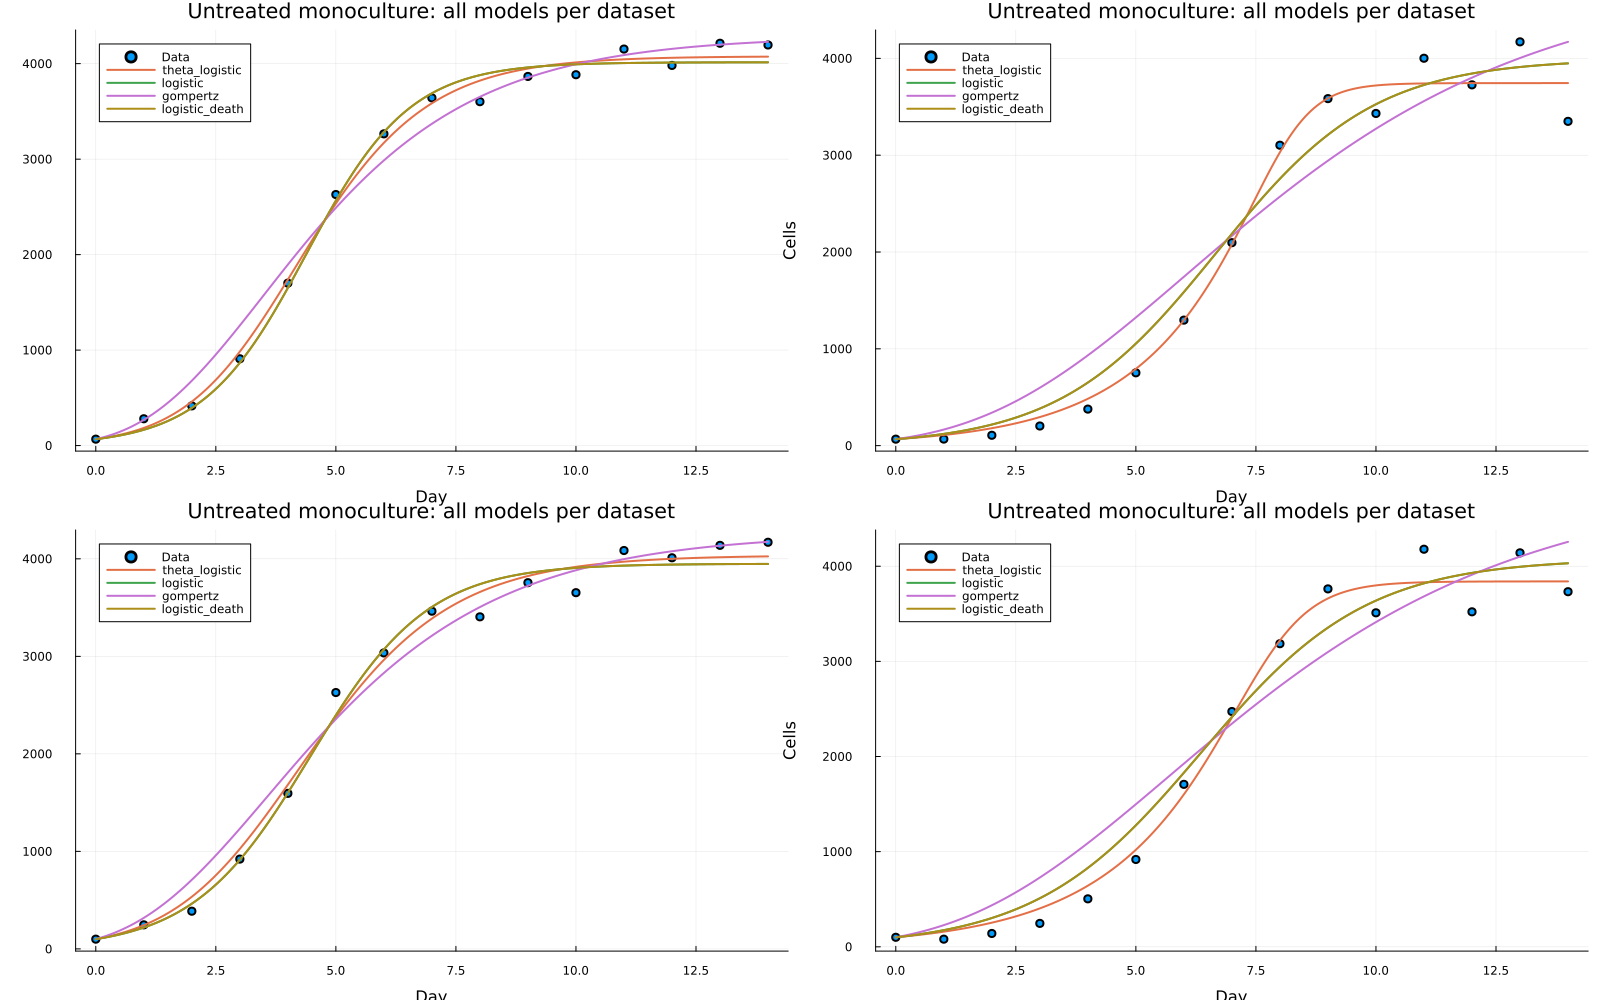

16×10 DataFrame
 Row │ File                         Density  CellLine    Model           SSR             BIC      r         K        v           d          
     │ String                       String   String      String          Float64         Float64  Float64   Float64  Float64     Float64    
─────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ A2780Naive_day_averages.csv  20k      A2780Naive  theta_logistic  165077.0        139.169  1.13666   4077.24    0.624115  NaN
   2 │ A2780Naive_day_averages.csv  20k      A2780Naive  logistic             2.18174e5  140.434  0.929374  4014.81  NaN         NaN
   3 │ A2780Naive_day_averages.csv  20k      A2780Naive  gompertz             4.49579e5  150.556  0.406996  4287.94  NaN         NaN
   4 │ A2780Naive_day_averages.csv  20k      A2780Naive  logistic_death       2.18174e5  143.073  1.6674    7203.02  NaN           0.738028
   5 │ A2780cis_day_av

  A2780 (Naive): r = 1.136659 day⁻¹, K = 4077.24 cells, v = 0.624
  A2780cis (Resistant): r = 0.494429 day⁻¹, K = 3744.54 cells, v = 3.951
  A2780 (Naive): r = 1.054519 day⁻¹, K = 4035.57 cells, v = 0.575
  A2780cis (Resistant): r = 0.465250 day⁻¹, K = 3840.31 cells, v = 3.287

GLOBAL BIC ANALYSIS ACROSS ALL DATASETS
  theta_logistic    global BIC = 597.110
  logistic          global BIC = 612.894
  logistic_death    global BIC = 623.450
  gompertz          global BIC = 652.437

Best model by global BIC (sum over all datasets):
  theta_logistic  (global BIC = 597.110)


In [29]:
# batch_untreated_monoculture.jl

using CSV
using DataFrames
using Printf
using Plots
using .Main: load_day_averages, infer_density, fit_growth_model, MODEL_SPECS

# -------------------------------------------------------
# 0) Models to fit (keys must exist in MODEL_SPECS)
# -------------------------------------------------------

const MODELS_TO_FIT = [
    :theta_logistic,
    :logistic,
    :gompertz,
    :logistic_death
]

# Model used for the "classic logistic" summary (theta-logistic here)
const LOGISTIC_MODEL_FOR_SUMMARY = :theta_logistic

# -------------------------------------------------------
# 1) Locate expected day-average CSVs
# -------------------------------------------------------

# Navigate to project root (go up 2 levels from notebook directory)
project_root = dirname(dirname(pwd()))

roots = [
    joinpath(project_root, "Processed_Datasets", "Untreated MonoCulture", "20k", "Averages"),
    joinpath(project_root, "Processed_Datasets", "Untreated MonoCulture", "30k", "Averages"),
]

# Expected files for verification in each root
expected_files = [
    "A2780Naive_day_averages.csv",
    "A2780cis_day_averages.csv",
]

files = String[]
for r in roots
    if isdir(r)
        #println("Checking directory: $r")
        for expected_file in expected_files
            full_path = joinpath(r, expected_file)
            if isfile(full_path)
                push!(files, full_path)
                #println("  ✓ Found: $expected_file")
            else
                @warn "  ✗ Missing: $expected_file"
            end
        end
    else
        @warn "Directory not found: $r"
    end
end

if isempty(files)
    @warn "No day averages CSVs found under Untreated MonoCulture"
else
    #println("\nProcessing $(length(files)) day-average files...")
end

# -------------------------------------------------------
# 2) Plot helpers
# -------------------------------------------------------

function make_fit_plot(
    x,
    y,
    sol;
    title_str::AbstractString = "Growth fit",
    yerr = nothing,
    density::String = "",
    model_label::AbstractString = "Model",
)
    # Copy inputs so we can extend them
    x_scatter = collect(Float64.(x))
    y_scatter = collect(Float64.(y))
    yerr_scatter = yerr === nothing ? nothing : collect(Float64.(yerr))

    # Day-0 value from density for plotting only
    day0_cells = if density == "30k"
        100.0
    elseif density == "20k"
        67.0
    else
        nothing
    end

    # Prepend a day-0 point if appropriate
    if day0_cells !== nothing && (isempty(x_scatter) || x_scatter[1] > 0.0)
        x_scatter = vcat(0.0, x_scatter)
        y_scatter = vcat(day0_cells, y_scatter)
        if yerr_scatter !== nothing
            yerr_scatter = vcat(0.0, yerr_scatter)  # no error bar at day 0
        end
    end

    # Scatter of data with optional error bars
    if yerr_scatter === nothing
        p = scatter(
            x_scatter, y_scatter;
            label = "Data",
            xlabel = "Day",
            ylabel = "Cells",
            title = title_str,
            markersize = 4,
        )
    else
        p = scatter(
            x_scatter, y_scatter;
            yerr = yerr_scatter,
            label = "Data",
            xlabel = "Day",
            ylabel = "Cells",
            title = title_str,
            markersize = 4,
        )
    end

    # Model curve from day 0
    plot!(p, sol.t, getindex.(sol.u, 1);
          label = model_label,
          linewidth = 2)

    return p
end

# Build a plot for one dataset with all models overlaid
function make_dataset_all_models_plot(
    d::Dict{Symbol,Any};
    models::Vector{Symbol} = MODELS_TO_FIT,
)
    x         = d[:x]
    y         = d[:y]
    yerr      = d[:yerr]
    density   = d[:density]
    cell_line = d[:cell_line]

    title_str = "$(density) • " *
        (cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)")

    # Data + optional error bars + day-0 point
    x_scatter = collect(Float64.(x))
    y_scatter = collect(Float64.(y))
    yerr_scatter = yerr === nothing ? nothing : collect(Float64.(yerr))

    day0_cells = if density == "30k"
        100.0
    elseif density == "20k"
        67.0
    else
        nothing
    end

    if day0_cells !== nothing && (isempty(x_scatter) || x_scatter[1] > 0.0)
        x_scatter = vcat(0.0, x_scatter)
        y_scatter = vcat(day0_cells, y_scatter)
        if yerr_scatter !== nothing
            yerr_scatter = vcat(0.0, yerr_scatter)
        end
    end

    if yerr_scatter === nothing
        p = scatter(
            x_scatter, y_scatter;
            label = "Data",
            xlabel = "Day",
            ylabel = "Cells",
            title  = title_str,
            markersize = 4,
        )
    else
        p = scatter(
            x_scatter, y_scatter;
            yerror = yerr_scatter,
            label  = "Data",
            xlabel = "Day",
            ylabel = "Cells",
            title  = title_str,
            markersize = 4,
        )

        ymin = minimum(y_scatter .- yerr_scatter)
        ylo  = ymin * 0.9
        ylims!(p, ylo, nothing)
    end

    # Overlay each model's curve
    for model in models
        if haskey(d[:fits], model)
            sol = d[:fits][model].sol
            plot!(p, sol.t, getindex.(sol.u, 1);
                  label    = string(model),
                  linewidth = 2)
        end
    end

    return p
end


# -------------------------------------------------------
# 3) Results tables
# -------------------------------------------------------

# Full multi-model results (fixed schema; NaN if param not used by model)
all_results = DataFrame(
    File     = String[],
    Density  = String[],
    CellLine = String[],
    Model    = String[],
    SSR      = Float64[],
    BIC      = Float64[],
    r        = Float64[],
    K        = Float64[],
    v        = Float64[],
    d        = Float64[]
)

# Logistic-only (theta-logistic) summary table
logistic_results = DataFrame(
    File     = String[],
    Density  = String[],
    CellLine = String[],
    r        = Float64[],
    K        = Float64[],
    v        = Float64[],
    SSR      = Float64[],
    BIC      = Float64[],
)

# Store data + fits per dataset for later plotting
datasets = Dict{Symbol,Any}[]  # each Dict has :file, :density, :cell_line, :x, :y, :yerr, :fits

# Global BIC accumulators per model
global_bic = Dict{Symbol,Float64}()

# -------------------------------------------------------
# 4) Fit all models on all files
# -------------------------------------------------------

for f in files
    try
        x, y, yerr = load_day_averages(f)

        # --- Fit only up to day 14 ---
        cutoff = 14
        mask = x .<= cutoff
        x = x[mask]
        y = y[mask]
        if yerr !== nothing
            yerr = yerr[mask]
        end

        den = infer_density(f)

        filename  = basename(f)
        cell_line = split(filename, "_")[1]
        cell_type = cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)"

        ds = Dict{Symbol,Any}()
        ds[:file]      = filename
        ds[:density]   = den
        ds[:cell_line] = cell_line
        ds[:x]         = x
        ds[:y]         = y
        ds[:yerr]      = yerr
        ds[:fits]      = Dict{Symbol,NamedTuple}()

        #println("\nFitting all models for $filename ($den, $cell_type)...")

        for model in MODELS_TO_FIT
            if !haskey(MODEL_SPECS, model)
                @warn "Model $model not found in MODEL_SPECS; skipping"
                continue
            end

            gfr, sol = fit_growth_model(
                x, y;
                model   = model,
                yerr    = yerr,
                density = den,
            )

            # Record fit for later plotting
            ds[:fits][model] = (gfr = gfr, sol = sol)

            # Extract parameters, defaulting to NaN if not present
            p          = gfr.params
            r_val      = get(p, :r,     NaN)
            K_val      = get(p, :K,     NaN)
            v_val      = get(p, :v,     NaN)
            d_val      = get(p, :d,     NaN)

            # Push a single fixed-length row into all_results
            push!(all_results, (
                filename,
                den,
                cell_line,
                string(model),
                gfr.SSR,
                gfr.BIC,
                r_val,
                K_val,
                v_val,
                d_val
            ))

            # Accumulate global BIC
            global_bic[model] = get(global_bic, model, 0.0) + gfr.BIC

            # Logistic summary
            if model == LOGISTIC_MODEL_FOR_SUMMARY
                push!(logistic_results, (
                    filename,
                    den,
                    cell_line,
                    r_val,
                    K_val,
                    v_val,
                    gfr.SSR,
                    gfr.BIC,
                ))
                #println("  [$(string(model))] r=$(round(r_val, digits=6)), K=$(round(K_val, digits=2)), v=$(round(v_val, digits=3))")
            else
                #println("  [$(string(model))] SSR=$(round(gfr.SSR, digits=3)), BIC=$(round(gfr.BIC, digits=3))")
            end
        end

        push!(datasets, ds)

    catch e
        @warn "Failed on $(basename(f)): $e"
    end
end

# -------------------------------------------------------
# 5) Four large plots: one per dataset with all models
# -------------------------------------------------------

if !isempty(datasets)
    # Ensure consistent ordering in grids (density then cell line)
    sort!(datasets, by = d -> (d[:density], d[:cell_line]))

    panels = Plots.Plot[]
    for d in datasets
        p = make_dataset_all_models_plot(d; models = MODELS_TO_FIT)
        push!(panels, p)
    end

    plt_all = plot(
        panels...;
        layout = (2, 2),
        size   = (1600, 1000),  # larger figure for readability
        title  = "Untreated monoculture: all models per dataset",
    )
    display(plt_all)
end

# -------------------------------------------------------
# 6) Export results
# -------------------------------------------------------

#println("\nDetailed multi-model results:")
println(all_results)

output_dir = pwd()

# Logistic (theta-logistic) parameters
logistic_file = joinpath(output_dir, "untreated_monoculture_logistic_parameters.csv")
CSV.write(logistic_file, logistic_results)
#println("\n✓ Logistic (theta-logistic) results exported to: ", logistic_file)

# Full model zoo results
allmodels_file = joinpath(output_dir, "untreated_monoculture_all_models_parameters.csv")
CSV.write(allmodels_file, all_results)
#println("✓ Full multi-model results exported to: ", allmodels_file)

# -------------------------------------------------------
# 7) Logistic-only summary across 4 datasets
# -------------------------------------------------------

#println("\n" * "="^60)
#println("COMPREHENSIVE SUMMARY OF r, K, v (model = $(string(LOGISTIC_MODEL_FOR_SUMMARY)))")
#println("="^60)
#println("All 4 datasets (both cell lines × both densities):")
#println()

for density in ["20k", "30k"]
    #println("$density Density:")
    #println("-" ^ 20)
    for cell_line in ["A2780Naive", "A2780cis"]
        row = filter(r -> r.Density == density && r.CellLine == cell_line, logistic_results)
        cell_type = cell_line == "A2780Naive" ? "A2780 (Naive)" : "A2780cis (Resistant)"

        if nrow(row) > 0
            r_val = row[1, :r]
            k_val = row[1, :K]
            v_val = row[1, :v]
            @printf("  %s: r = %.6f day⁻¹, K = %.2f cells, v = %.3f\n",
                    cell_type, r_val, k_val, v_val)
        else
            #println("  $cell_type: Data not found for model $(string(LOGISTIC_MODEL_FOR_SUMMARY))")
        end
    end
    #println()
end

#println("Day 0 cell counts used:")
#println("  20k seeding density: 67 cells   # calculated by hand from plate setup")
#println("  30k seeding density: 100 cells  # calculated by hand from plate setup")
#println("  Data normalization: Applied in fitting to reduce bias toward larger values")
#println("  Error bars (SEM/SD): Used for weighted fitting when available")

# -------------------------------------------------------
# 8) Global BIC analysis across all 4 datasets
# -------------------------------------------------------

println("\n" * "="^60)
println("GLOBAL BIC ANALYSIS ACROSS ALL DATASETS")
println("="^60)

if isempty(global_bic)
    println("No BIC values recorded (no successful fits).")
else
    # Sort models by global BIC
    sorted_bic = sort(collect(global_bic); by = kv -> kv[2])

    # Print per-model global BIC
    for (model, bic_sum) in sorted_bic
        @printf("  %-16s  global BIC = %.3f\n", string(model), bic_sum)
    end

    best_model, best_bic = sorted_bic[1]

    println()
    println("Best model by global BIC (sum over all datasets):")
    @printf("  %s  (global BIC = %.3f)\n", string(best_model), best_bic)
end


Notes to interpret:

v < 1 means an early saturation constant
v > 1 means a late saturation constant
v = 1 is standard logistic growth

Note naive cells have early saturation constants while resistant has late saturation constants. 

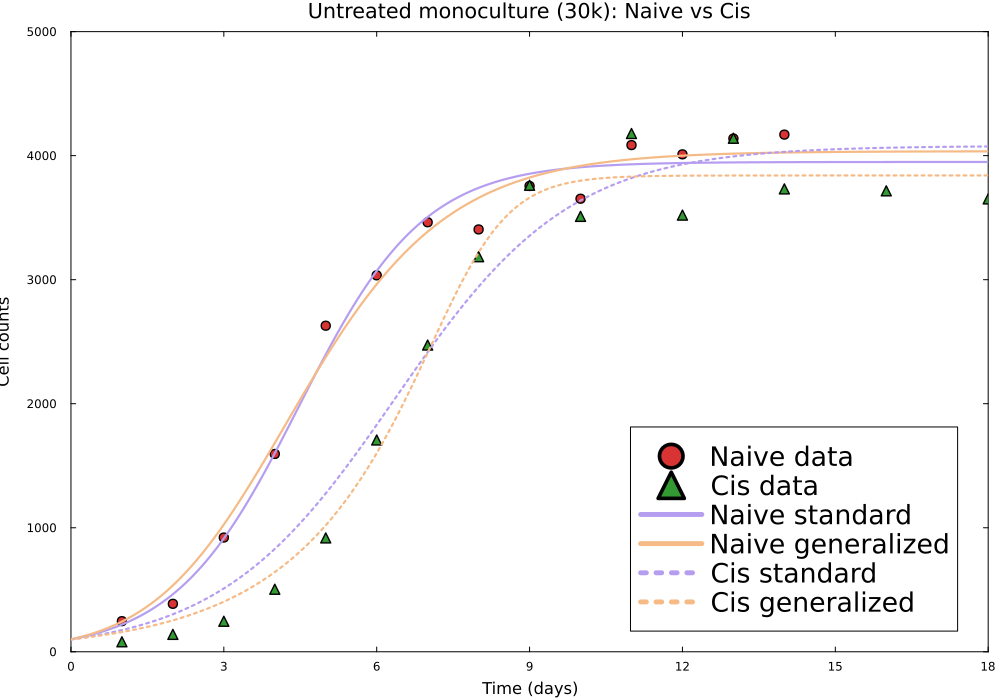

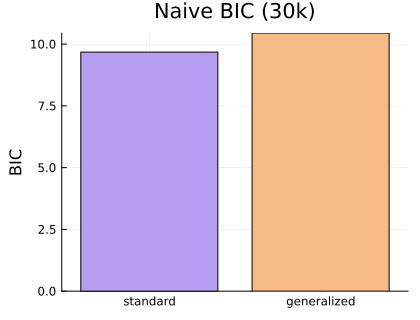

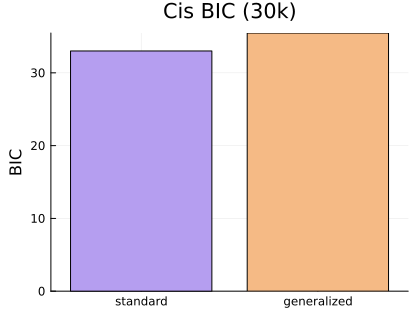

In [30]:
begin
using CSV, DataFrames, DifferentialEquations, Plots

# --- Colors / styling ---
naive_color = RGB(0.85, 0.2, 0.2)   # red
cis_color   = RGB(0.2, 0.6, 0.2)    # green
standard_color = RGB(0.71, 0.62, 0.94)   # lavender
general_color  = RGB(0.96, 0.73, 0.52)   # light orange


axis_kw = (; xlabel="Time (days)", ylabel="Cell counts",
           ylims=(0, 5000), grid=false, framestyle=:box,
           background_color=:white)

# --- Paths ---
project_root = dirname(dirname(pwd()))
function load_day_avg(cell_line::String, density::String)
    path = joinpath(project_root, "Processed_Datasets", "Untreated MonoCulture", density,
                    "Averages", "$(cell_line)_day_averages.csv")
    df = CSV.read(path, DataFrame)
    return Float64.(df.Day), Float64.(df."Mean Cells")
end

# --- ODEs ---
function logistic_simple!(du, u, p, t)
    r, K = p
    du[1] = r * u[1] * (1 - u[1] / K)
end
function theta_logistic!(du, u, p, t)
    r, K, v = p
    du[1] = r * u[1] * (1 - (u[1] / K)^v)
end

# --- Saved fit parameters (30k only used here) ---
theta_params = Dict(
    ("A2780Naive","30k") => (r=1.0545191246120271, K=4035.569668730678, v=0.5748389959027119),
    ("A2780cis","30k")   => (r=0.46525046204331894, K=3840.3070590669213, v=3.287467937981959),
)
logistic_params = Dict(
    ("A2780Naive","30k") => (r=0.8168872013770703, K=3949.1283962613634),
    ("A2780cis","30k")   => (r=0.5795510240007554, K=4078.7608559864702),
)
density_day0 = Dict("30k" => 100.0)

function solve_curve(model::Symbol, cell_line::String, density::String, tmax::Real)
    u0 = [density_day0[density]]
    tspan = (0.0, tmax)
    tplot = range(0, tmax; length=300)
    if model == :standard
        p = logistic_params[(cell_line, density)]
        prob = ODEProblem(logistic_simple!, u0, tspan, (p.r, p.K))
    elseif model == :general
        p = theta_params[(cell_line, density)]
        prob = ODEProblem(theta_logistic!, u0, tspan, (p.r, p.K, p.v))
    else
        error("Unknown model: $model")
    end
    sol = solve(prob, Tsit5(); saveat=tplot, reltol=1e-9, abstol=1e-9)
    return sol.t, getindex.(sol.u, 1)
end

# --- Load 30k data ---
x_naive, y_naive = load_day_avg("A2780Naive", "30k")
x_cis,   y_cis   = load_day_avg("A2780cis", "30k")
tmax = max(maximum(x_naive), maximum(x_cis))

# --- Model curves ---
t_std_naive, y_std_naive = solve_curve(:standard, "A2780Naive", "30k", tmax)
t_gen_naive, y_gen_naive = solve_curve(:general,  "A2780Naive", "30k", tmax)
t_std_cis,   y_std_cis   = solve_curve(:standard, "A2780cis", "30k", tmax)
t_gen_cis,   y_gen_cis   = solve_curve(:general,  "A2780cis", "30k", tmax)

# --- Plot ---
p = plot(; title="Untreated monoculture (30k): Naive vs Cis",
         xlims=(0, tmax), size=(1000, 700), axis_kw...,
         legend=:bottomright, legendfontsize=18)

scatter!(p, x_naive, y_naive; label="Naive data", markersize=5, markercolor=naive_color, markershape=:circle)
scatter!(p, x_cis, y_cis; label="Cis data", markersize=5, markercolor=cis_color, markershape=:utriangle)

plot!(p, t_std_naive, y_std_naive; label="Naive standard", color=standard_color, linestyle=:solid, linewidth=2.2)
plot!(p, t_gen_naive, y_gen_naive; label="Naive generalized", color=general_color, linestyle=:solid, linewidth=2.2)

plot!(p, t_std_cis, y_std_cis; label="Cis standard", color=standard_color, linestyle=:dot, linewidth=2.2)
plot!(p, t_gen_cis, y_gen_cis; label="Cis generalized", color=general_color, linestyle=:dot, linewidth=2.2)


display(p)
end

# --- BIC plots (Naive + cis) ---
function simulate_at_times(x_in, model::Symbol, cell_line::String, density::String)
    x = Float64.(x_in)
    ord = sortperm(x); xs = x[ord]
    u0 = [density_day0[density]]
    tspan = (xs[1], xs[end])

    if model == :standard
        p = logistic_params[(cell_line, density)]
        prob = ODEProblem(logistic_simple!, u0, tspan, (p.r, p.K))
    elseif model == :general
        p = theta_params[(cell_line, density)]
        prob = ODEProblem(theta_logistic!, u0, tspan, (p.r, p.K, p.v))
    else
        error("Unknown model: $model")
    end

    sol = solve(prob, Tsit5(); saveat=xs, reltol=1e-9, abstol=1e-9)
    y_sorted = getindex.(sol.u, 1)
    yhat = similar(y_sorted); yhat[ord] = y_sorted
    return yhat
end

bic_from_rss(RSS::Real, n::Int, k::Int) = n * log(max(RSS, eps(Float64)) / n) + k * log(n)

function bic_for_cell(cell_line::String, density::String)
    x, y = load_day_avg(cell_line, density)
    yhat_std = simulate_at_times(x, :standard, cell_line, density)
    yhat_gen = simulate_at_times(x, :general,  cell_line, density)

    RSS_std = sum((y .- yhat_std).^2)
    RSS_gen = sum((y .- yhat_gen).^2)

    n = length(y)
    BIC_std = bic_from_rss(RSS_std, n, 2)
    BIC_gen = bic_from_rss(RSS_gen, n, 3)

    return BIC_std-165, BIC_gen-165  # offset for plotting
end

bic_naive_std, bic_naive_gen = bic_for_cell("A2780Naive", "30k")
bic_cis_std,   bic_cis_gen   = bic_for_cell("A2780cis", "30k")

p_bic_naive = bar(["standard", "generalized"], [bic_naive_std, bic_naive_gen];
                  color=[standard_color, general_color], legend=false,
                  title="Naive BIC (30k)", xlabel="", ylabel="BIC", size=(420, 320))

p_bic_cis = bar(["standard", "generalized"], [bic_cis_std, bic_cis_gen];
                color=[standard_color, general_color], legend=false,
                title="Cis BIC (30k)", xlabel="", ylabel="BIC", size=(420, 320))

display(p_bic_naive)
display(p_bic_cis)

